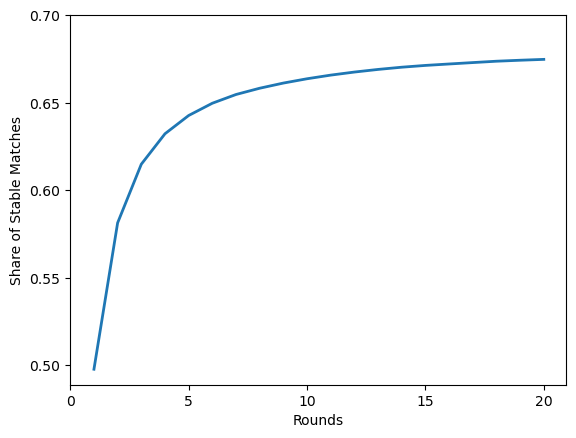

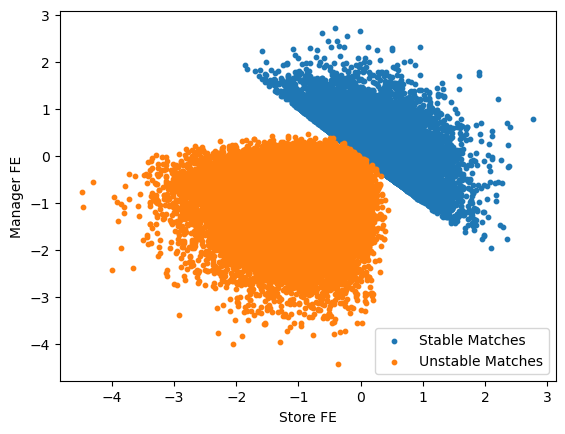

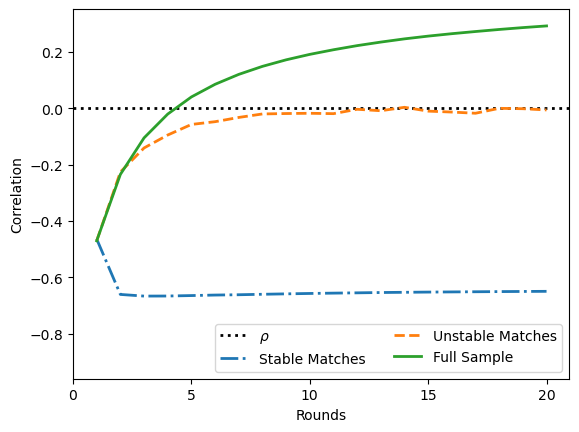

In [12]:
#%% importing all necessary modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

#%% Set directory

os.chdir("/files/JPE-Sollaci-20240098/replication-package/Replication/CodeA/NAM Simulations")
script_dir = os.getcwd()
parent_dir = os.path.dirname(os.path.dirname(script_dir))
figures_dir = os.path.join(parent_dir, "Results", "Figures")

#%% Parameters

mean_s = 0
sigma_s = 1

mean_m = 0
sigma_m = 1

rho = 0
k = 0

N = 100000

# Iterations
max_iter = 20
stable_corr = np.zeros(max_iter)
unstable_corr = np.zeros(max_iter)
share_stable = np.zeros(max_iter)
obs_corr = np.zeros(max_iter)
obs_corr_new = np.zeros(max_iter)


#%% Draw qualities

mean = [mean_s, mean_m]
cov = np.array(
    [[sigma_s**2, rho*(sigma_s**2 * sigma_m**2)**(1/2)],[rho*(sigma_s**2 * sigma_m**2)**(1/2), sigma_m**2]]
    )

fe = np.random.multivariate_normal(mean, cov, N)
s_fe = fe[:,0]
m_fe = fe[:,1]

#%% First round: find unstable matches and sort again

stable_match = s_fe + m_fe > k

# save numbers (pre-reshuffle)
share_stable[0] = len(s_fe[stable_match])/N

stable_corr[0] = np.corrcoef(s_fe[stable_match], m_fe[stable_match])[0,1]
unstable_corr[0] = np.corrcoef(s_fe[~stable_match], m_fe[~stable_match])[0,1]
obs_corr[0] = unstable_corr[0]
obs_corr_new[0] = unstable_corr[0]

# transform into dataframe
stable_s = pd.DataFrame(s_fe[stable_match], columns=["store"])
unstable_s = pd.DataFrame(s_fe[~stable_match], columns=["store"])

stable_m = pd.DataFrame(m_fe[stable_match], columns=["manager"])
unstable_m = pd.DataFrame(m_fe[~stable_match], columns=["manager"])

# draw auxiliary variables and rank
new_match = pd.DataFrame(np.random.multivariate_normal(mean, cov, len(unstable_s["store"])),
                         columns=["store", "manager"])

new_match["store_rank"] = new_match["store"].rank()
new_match["manager_rank"] = new_match["manager"].rank()
new_match = new_match.drop(columns=["store", "manager"])

# rank unstable matchs and merge
unstable_s["store_rank"] = unstable_s["store"].rank()
unstable_m["manager_rank"] = unstable_m["manager"].rank()

new_match = pd.merge(new_match, unstable_s, on=["store_rank"])
new_match = pd.merge(new_match, unstable_m, on=["manager_rank"])

new_s = np.array(new_match["store"])
new_m = np.array(new_match["manager"])

# observed matches: all of the unstable + new ones
obs_s = np.append(np.array(unstable_s["store"]), new_s)
obs_m = np.append(np.array(unstable_m["manager"]), new_m)

#%% Iterate!

# since only the first round has passed, all matches are new
s_fe = new_s
m_fe = new_m

for n in range(1,max_iter):
    
    stable_match = s_fe + m_fe > k
    #print("correlation of unstable matches:", np.corrcoef(s_fe[~stable_match], m_fe[~stable_match])[0,1])
    #print("correlation of stable matches:", np.corrcoef(s_fe[stable_match], m_fe[stable_match])[0,1])
    #print("share of stable matches:", len(s_fe[stable_match])/(len(s_fe[stable_match])+len(s_fe[~stable_match])))
    
    share_stable[n] =  len(s_fe[stable_match])/N + share_stable[0]
    # since we dropped all original (unobserved) stable matches, need to add them back to the share
    
    stable_corr[n] = np.corrcoef(s_fe[stable_match], m_fe[stable_match])[0,1]
    unstable_corr[n] = np.corrcoef(s_fe[~stable_match], m_fe[~stable_match])[0,1]
    obs_corr[n] = np.corrcoef(obs_s, obs_m)[0,1]
    
    # transform into dataframe
    stable_s = pd.DataFrame(s_fe[stable_match], columns=["store"])
    unstable_s = pd.DataFrame(s_fe[~stable_match], columns=["store"])
    
    stable_m = pd.DataFrame(m_fe[stable_match], columns=["manager"])
    unstable_m = pd.DataFrame(m_fe[~stable_match], columns=["manager"])
    
    # draw auxiliary variables and rank
    new_match = pd.DataFrame(np.random.multivariate_normal(mean, cov, len(unstable_s["store"])),
                             columns=["store", "manager"])
    
    new_match["store_rank"] = new_match["store"].rank()
    new_match["manager_rank"] = new_match["manager"].rank()
    new_match = new_match.drop(columns=["store", "manager"])
    
    # rank unstable matches and merge
    unstable_s["store_rank"] = unstable_s["store"].rank()
    unstable_m["manager_rank"] = unstable_m["manager"].rank()
    
    new_match = pd.merge(new_match, unstable_s, on=["store_rank"])
    new_match = pd.merge(new_match, unstable_m, on=["manager_rank"])
 
    new_s = np.array(new_match["store"])
    new_m = np.array(new_match["manager"])   
    
    # qualities are now the stable matches (after 1st round) plus the new matches
    s_fe = np.append(np.array(stable_s["store"]), new_s)
    m_fe = np.append(np.array(stable_m["manager"]), new_m)
        
    
    #check: the size of the FE vector should be stable
    #print("number of managers", s_fe.shape)
    #print("size of observed data", obs_s.shape)
    
    # observed matches: initial matches, plus new matches after reshuffle 
    obs_s = np.append(obs_s, s_fe)
    obs_m = np.append(obs_m, m_fe)   
    



#%% Plots: Figure D.3
rounds = np.linspace(1, max_iter, len(obs_corr))

# Panel a
plt.plot(rounds, share_stable, linewidth=2)
plt.xlabel("Rounds") 
plt.ylabel("Share of Stable Matches")
plt.xticks(np.arange(0, 21, step=5))
plt.yticks(np.arange(.50, .71, step=.05))
save_path = os.path.join(figures_dir, "Figure_D3a.png")
plt.savefig(save_path, dpi=300)
plt.show()

# Panel b
stable_match = s_fe + m_fe > k
plt.scatter(s_fe[stable_match], m_fe[stable_match], label="Stable Matches", s=10)
plt.scatter(s_fe[~stable_match], m_fe[~stable_match], label="Unstable Matches", s=10)
plt.xlabel("Store FE") 
plt.ylabel("Manager FE")
plt.legend(loc="lower right", ncol=1)
save_path = os.path.join(figures_dir, "Figure_D3b.png")
plt.savefig(save_path, dpi=300)
plt.show()

# Panel c
plt.axhline(y = rho, color = 'k', linestyle = 'dotted', linewidth=2, label=r"$\rho$")
plt.plot(rounds, stable_corr, linewidth=2, linestyle = 'dashdot', label="Stable Matches")
plt.plot(rounds, unstable_corr, linewidth=2, linestyle = 'dashed', label="Unstable Matches")
plt.plot(rounds, obs_corr, linewidth=2, label="Full Sample")
plt.plot(rounds, -0.9*np.ones(len(rounds)), linestyle=" ")
plt.ylabel("Correlation")
plt.xlabel("Rounds")
plt.xticks(np.arange(0, 21, step=5))
plt.legend(loc="lower right", ncol=2)
#plt.legend(loc=(0.1, 1.05), ncol=2)
save_path = os.path.join(figures_dir, "Figure_D3c.png")
plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.show()


In [4]:
print(os.path.exists(figures_dir))

False


In [11]:
import os
print(os.getcwd())

/files
